# Impact Score vs. Allele Frequency — Systematic Score Selection

**Paper Figure 2B — MAGI Framework (v2, refactored)**

Systematically evaluates candidate impact scores across multiple aggregation
methods and feature groups, then generates a publication-quality scatter of
the winning score vs. gnomAD allele frequency.

### Score Taxonomy

| Group | Columns | Aggregations | Notes |
|-------|---------|--------------|-------|
| **BED** | 21 `D_BED_*` | mean\|Δ\|, max\|Δ\|, Σln(1+\|Δ\|), top-3 mean | Raw absolute genomic-element deltas |
| **BW** | 3,602 `D_BW_*` | mean\|z\|, max\|z\|, Σln(1+\|z\|), top-10 mean | Z-scored (per-type benign baseline) |
| **MLM** | 8 features | Each individually (+ \|abs\| for signed) | LLR, KL, logprob, Δ, Prior |
| **EMB** | 4 features | Each individually | Indel-only embedding distances |
| **Global** | 3,623 `D_*` | mean\|z\|, max\|z\|, Σln(1+\|z\|) | All deltas z-scored uniformly |
| **Composite** | BED + BW | 0.5 × BED + 0.5 × BW | Balanced cross-group average |

**Evaluation:** AUC, Cohen's d, rank-biserial r, KS statistic on Pathogenic vs. Benign.

**Data:** ClinVar SNP + Indel delta profiles from NTv3 foundation model.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════════════════════════════
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.metrics import roc_auc_score

# ── Publication style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update(
    {
        "savefig.dpi": 300,
        "savefig.format": "pdf",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,  # TrueType → editable text
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.figsize": (8, 6),
        "font.size": 11,
    }
)

LABEL_COLORS = {"Pathogenic": "#d73027", "Benign": "#4575b4"}
AF_RARE = 1e-4  # 0.01 %
AF_COMMON = 0.01  # 1 % (ACMG BA1)
FIG_DIR = Path("analyses/figures/impact_vs_af")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


---
## 1. Data Loading, Concatenation &amp; AF Merge

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1a. LOAD & CONCATENATE DELTA PARQUETS
# ═══════════════════════════════════════════════════════════════════════════════
snp_df = pd.read_parquet("clinvar_new_deltas.parquet")
indel_df = pd.read_parquet("clinvar_indel_deltas.parquet")

# Tag variant type
snp_df["variant_type"] = "SNP"
if "variant_type" not in indel_df.columns:
    indel_df["variant_type"] = "Indel"

# Harmonize labels → string
snp_df["label"] = snp_df["label"].map({True: "Pathogenic", False: "Benign"})
indel_df["label"] = indel_df["label"].map({1: "Pathogenic", 0: "Benign"})

df = pd.concat([snp_df, indel_df], axis=0, ignore_index=True)
del snp_df, indel_df

print(f"Combined: {len(df):,} variants × {df.shape[1]:,} columns")
print(f"Labels:  {df['label'].value_counts().to_dict()}")
print(f"Types:   {df['variant_type'].value_counts().to_dict()}")

Combined: 54,040 variants × 7,278 columns
Labels:  {'Pathogenic': 34233, 'Benign': 19807}
Types:   {'SNP': 40976, 'Deletion': 11579, 'Insertion': 845, 'Indel': 640}


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1b. ALLELE FREQUENCY MERGE
# ═══════════════════════════════════════════════════════════════════════════════
af = pd.concat(
    [
        pd.read_csv("data/stav_data/stav data/AFs/snps_AF_sub.csv"),
        pd.read_csv("data/stav_data/stav data/AFs/indel_AF_sub.csv"),
    ],
    ignore_index=True,
)

# Clean: "-" → NaN, coerce to float
for c in (c for c in af.columns if c.startswith("gnomAD") or c == "UKBB_AF"):
    af[c] = pd.to_numeric(af[c].replace("-", np.nan), errors="coerce")
af = af.drop_duplicates(subset=["chrom", "pos", "ref", "alt"], keep="first")

n_pre = len(df)
df = df.merge(
    af[["chrom", "pos", "ref", "alt", "gnomADe_AF"]],
    on=["chrom", "pos", "ref", "alt"],
    how="left",
)
assert len(df) == n_pre, f"Row count changed: {n_pre} → {len(df)}"
del af

has_af = df["gnomADe_AF"].notna()
print(f"\nWith gnomAD AF: {has_af.sum():,} / {len(df):,} ({has_af.mean():.1%})")
for lbl in ["Pathogenic", "Benign"]:
    m = df["label"] == lbl
    h = df.loc[m, "gnomADe_AF"].notna()
    print(f"  {lbl:12s}: {h.sum():>6,} / {m.sum():>6,} ({h.mean():.1%})")
print(
    "⚠  Selection bias: pathogenic variants are often ultra-rare or absent from gnomAD."
)


With gnomAD AF: 10,063 / 54,040 (18.6%)
  Pathogenic  :  6,772 / 34,233 (19.8%)
  Benign      :  3,291 / 19,807 (16.6%)
⚠  Selection bias: pathogenic variants are often ultra-rare or absent from gnomAD.


---
## 2. Feature Groups &amp; Column Taxonomy

We work exclusively with **delta** columns (`D_BED_*`, `D_BW_*`) — never reference
values (`REF_BED_*`, `REF_BW_*`).

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. FEATURE GROUP TAXONOMY
# ═══════════════════════════════════════════════════════════════════════════════
D_BED = sorted(c for c in df.columns if c.startswith("D_BED_"))
D_BW = sorted(c for c in df.columns if c.startswith("D_BW_"))
MLM = [
    c
    for c in [
        "LLR",
        "MLM_Prior",
        "MLM_Delta",
        "MLM_KL_mean",
        "MLM_KL_max",
        "MLM_logprob_ref",
        "MLM_logprob_alt",
        "MLM_logprob_delta",
    ]
    if c in df.columns
]
EMB = sorted(c for c in df.columns if c.startswith("EMB_"))

# ── Safety: never REF columns ────────────────────────────────────────────────
assert all(c.startswith("D_BED_") for c in D_BED), "Non-delta BED column!"
assert all(c.startswith("D_BW_") for c in D_BW), "Non-delta BW column!"

print(f"{'Group':<10s} {'Cols':>6s}  Examples")
print(f"{'─' * 55}")
print(f"{'D_BED':<10s} {len(D_BED):>6,}  {D_BED[:4]} ...")
print(f"{'D_BW':<10s} {len(D_BW):>6,}  {D_BW[:3]} ...")
print(f"{'MLM':<10s} {len(MLM):>6,}  {MLM}")
print(f"{'EMB':<10s} {len(EMB):>6,}  {EMB}  (indel-only)")
print(f"\nBED elements ({len(D_BED)}): {[c.replace('D_BED_', '') for c in D_BED]}")

Group        Cols  Examples
───────────────────────────────────────────────────────
D_BED          21  ['D_BED_3UTR+', 'D_BED_3UTR-', 'D_BED_5UTR+', 'D_BED_5UTR-'] ...
D_BW        3,602  ['D_BW_CNhs10608_M', 'D_BW_CNhs10608_P', 'D_BW_CNhs10610_M'] ...
MLM             8  ['LLR', 'MLM_Prior', 'MLM_Delta', 'MLM_KL_mean', 'MLM_KL_max', 'MLM_logprob_ref', 'MLM_logprob_alt', 'MLM_logprob_delta']
EMB             4  ['EMB_cosine_dist', 'EMB_l2_dist', 'EMB_max_pos_dist', 'EMB_mean_pos_dist']  (indel-only)

BED elements (21): ['3UTR+', '3UTR-', '5UTR+', '5UTR-', 'CTCF-bound', 'ORF', 'always_on_exon', 'enhancer_Tissue_invariant', 'enhancer_Tissue_specific', 'exon', 'intron', 'lncRNA', 'polyA_signal', 'promoter_Tissue_invariant', 'promoter_Tissue_specific', 'protein_coding_gene', 'skipped_exon', 'splice_acceptor', 'splice_donor', 'start_codon', 'stop_codon']


---
## 3. Helper Functions &amp; Score Computation

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3a. HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════


def z_score_matrix(df, cols, benign_mask, per_type=True):
    """Z-score columns against benign distribution.

    When per_type=True each variant type gets its own benign baseline,
    preventing cross-type distributional contamination (analogous to
    batch correction).
    """
    matrix = df[cols].values.astype(np.float64)
    result = np.empty_like(matrix)

    groups = (
        df["variant_type"].unique()
        if (per_type and "variant_type" in df.columns)
        else [None]
    )
    for vt in groups:
        idx = (
            (df["variant_type"] == vt).values
            if vt is not None
            else np.ones(len(df), dtype=bool)
        )
        ben = idx & benign_mask
        if ben.sum() < 10:
            ben = benign_mask  # fallback to pooled benign
        mu = np.nanmean(matrix[ben], axis=0)
        sigma = np.nanstd(matrix[ben], axis=0)
        sigma[sigma < 1e-8] = 1.0  # guard zero-variance
        result[idx] = (matrix[idx] - mu) / sigma

    return result


def agg_scores(matrix, prefix):
    """Return {name: per-row array} for mean|x|, max|x|, Σln(1+|x|)."""
    am = np.abs(matrix)
    return {
        f"{prefix}_mean_abs": np.nanmean(am, axis=1),
        f"{prefix}_max_abs": np.nanmax(am, axis=1),
        f"{prefix}_sum_log": np.nansum(np.log1p(am), axis=1),  # ln(1+|x|)
    }


def top_k_mean(matrix, k):
    """Mean of top-k absolute values per row."""
    k = min(k, matrix.shape[1])
    return np.sort(np.abs(matrix), axis=1)[:, -k:].mean(axis=1)


def evaluate_score(values, labels_bin, name):
    """Compute discrimination metrics for a candidate score.

    Returns a dict with AUC (direction-agnostic), |Cohen's d|,
    rank-biserial r, KS statistic, sample sizes, and class means.
    Returns None if insufficient data.
    """
    valid = np.isfinite(values)
    v, y = values[valid], labels_bin[valid]
    if valid.sum() < 30 or y.sum() < 5 or (1 - y).sum() < 5:
        return None

    auc = roc_auc_score(y, v)
    auc = max(auc, 1.0 - auc)  # direction-agnostic

    p, b = v[y == 1], v[y == 0]
    pooled = np.sqrt(
        ((len(p) - 1) * p.std() ** 2 + (len(b) - 1) * b.std() ** 2)
        / max(len(p) + len(b) - 2, 1)
    )
    d = abs(p.mean() - b.mean()) / max(pooled, 1e-12)
    ks, ks_p = stats.ks_2samp(p, b)

    return dict(
        Score=name,
        AUC=auc,
        Cohen_d=d,
        Rank_Biserial_r=2 * auc - 1,
        KS_stat=ks,
        KS_pval=ks_p,
        N=int(valid.sum()),
        Path_mean=float(p.mean()),
        Ben_mean=float(b.mean()),
    )


# ── Score registry ────────────────────────────────────────────────────────────
# Each entry: (name, values_array, subset, group)
score_registry: list[tuple[str, np.ndarray, str, str]] = []


def register(name, values, subset="All", group=""):
    """Append a candidate score to the registry."""
    score_registry.append((name, np.asarray(values, dtype=np.float64), subset, group))


print("Helpers defined.  Score registry initialised.")

Helpers defined.  Score registry initialised.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3b. COMPUTE ALL CANDIDATE SCORES
# ═══════════════════════════════════════════════════════════════════════════════
score_registry.clear()  # avoid duplicate entries when this cell is re-run
benign_mask = (df["label"] == "Benign").values
label_bin = (df["label"] == "Pathogenic").astype(int).values

# ── BED group (raw absolute deltas, 21 cols) ─────────────────────────────────
bed_raw = df[D_BED].values.astype(np.float64)
for name, arr in agg_scores(np.abs(bed_raw), "BED").items():
    df[name] = arr
    register(name, arr, group="BED")
df["BED_top3_mean"] = top_k_mean(bed_raw, 3)
register("BED_top3_mean", df["BED_top3_mean"].values, group="BED")
print(f"✓ BED group: 4 scores from {len(D_BED)} columns")

# ── BW group (z-scored, 3602 cols) ───────────────────────────────────────────
print("  Z-scoring D_BW columns (per variant type)…")
bw_z = z_score_matrix(df, D_BW, benign_mask, per_type=True)
nan_ct = np.isnan(bw_z).sum()
if nan_ct:
    print(f"  ⚠ {nan_ct:,} NaN in BW z-scores → filling with 0")
    np.nan_to_num(bw_z, copy=False, nan=0.0)

bw_abs = np.abs(bw_z)  # |z-scored BW deltas|
for name, arr in agg_scores(bw_abs, "BW_z").items():
    df[name] = arr
    register(name, arr, group="BW")
df["BW_z_top10_mean"] = top_k_mean(bw_z, 10)
register("BW_z_top10_mean", df["BW_z_top10_mean"].values, group="BW")
print(f"✓ BW group:  4 scores from {len(D_BW)} columns")

# ── Global (all deltas z-scored uniformly: BED + BW) ─────────────────────────
bed_z = z_score_matrix(df, D_BED, benign_mask, per_type=True)
np.nan_to_num(bed_z, copy=False, nan=0.0)  # clean any z-score NaN
global_abs = np.hstack([np.abs(bed_z), bw_abs])
for name, arr in agg_scores(global_abs, "Global_z").items():
    df[name] = arr
    register(name, arr, group="Global")
print(f"✓ Global:    3 scores from {len(D_BED) + len(D_BW)} z-scored columns")
del bed_z, global_abs, bw_abs  # free ~3 GB

# ── Composite (balanced BED + BW) ────────────────────────────────────────────
df["Composite_mean"] = 0.5 * df["BED_mean_abs"] + 0.5 * df["BW_z_mean_abs"]
df["Composite_top"] = 0.5 * df["BED_top3_mean"] + 0.5 * df["BW_z_top10_mean"]
register("Composite_mean", df["Composite_mean"].values, group="Composite")
register("Composite_top", df["Composite_top"].values, group="Composite")
print(f"✓ Composite: 2 scores (balanced BED + BW average)")

# ── MLM features (individual, + |abs| for signed) ────────────────────────────
SIGNED_MLM = {
    "LLR",
    "MLM_Delta",
    "MLM_logprob_delta",
    "MLM_logprob_ref",
    "MLM_logprob_alt",
}
for col in MLM:
    register(col, df[col].values, group="MLM")
    if col in SIGNED_MLM:
        register(f"|{col}|", np.abs(df[col].values), group="MLM")
mlm_count = sum(1 for n, *_ in score_registry if _[-1] == "MLM")
print(f"✓ MLM:       {mlm_count} scores ({len(MLM)} features, +|abs| for signed)")

# ── EMB features (auto-subset: All if non-indel coverage is high) ────────────
indel_like_mask = (
    df["variant_type"]
    .isin(["Indel", "indel", "deletion", "insertion", "Deletion", "Insertion"])
    .values
)
non_indel_total = int((~indel_like_mask).sum())
emb_all_count, emb_indel_count = 0, 0

for col in EMB:
    vals = pd.to_numeric(df[col], errors="coerce").values.astype(np.float64)
    non_na = np.isfinite(vals)
    non_indel_non_na = int((non_na & ~indel_like_mask).sum())
    non_indel_cov = non_indel_non_na / max(non_indel_total, 1)

    subset = "All" if non_indel_cov >= 0.95 else "Indels"
    register(col, vals, subset=subset, group="EMB")

    if subset == "All":
        emb_all_count += 1
    else:
        emb_indel_count += 1

print(
    f"✓ EMB:       {len(EMB)} scores  (All: {emb_all_count}, Indel-only: {emb_indel_count}; "
    f"non-indel coverage threshold = 95%)"
)

print(f"\n{'═' * 55}")
print(f"Total candidate scores: {len(score_registry)}")
print(f"{'═' * 55}")

✓ BED group: 4 scores from 21 columns
  Z-scoring D_BW columns (per variant type)…


/tmp/ipykernel_40026/604836858.py:42: RuntimeWarning: Mean of empty slice
  f"{prefix}_mean_abs": np.nanmean(am, axis=1),
/tmp/ipykernel_40026/604836858.py:43: RuntimeWarning: All-NaN slice encountered
  f"{prefix}_max_abs": np.nanmax(am, axis=1),


  ⚠ 14,408 NaN in BW z-scores → filling with 0
✓ BW group:  4 scores from 3602 columns
✓ Global:    3 scores from 3623 z-scored columns
✓ Composite: 2 scores (balanced BED + BW average)
✓ MLM:       13 scores (8 features, +|abs| for signed)
✓ EMB:       4 scores  (All: 0, Indel-only: 4; non-indel coverage threshold = 95%)

═══════════════════════════════════════════════════════
Total candidate scores: 30
═══════════════════════════════════════════════════════


---
## 4. Score Evaluation &amp; Ranking

Every candidate is evaluated on its ability to discriminate **Pathogenic** vs.
**Benign** ClinVar variants.  Primary metric: **AUC** (direction-agnostic).
Secondary: **|Cohen's d|** (effect size), **KS statistic** (distribution separation).

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4a. EVALUATE ALL CANDIDATE SCORES
# ═══════════════════════════════════════════════════════════════════════════════
indel_mask = (
    df["variant_type"]
    .isin(["Indel", "indel", "deletion", "insertion", "Deletion", "Insertion"])
    .values
)

results = []
for name, values, subset, group in score_registry:
    if subset == "Indels":
        mask = indel_mask
    else:
        mask = np.ones(len(df), dtype=bool)
    res = evaluate_score(values[mask], label_bin[mask], name)
    if res is not None:
        res["Group"] = group
        res["Subset"] = subset
        results.append(res)

score_table = (
    pd.DataFrame(results).sort_values("AUC", ascending=False).reset_index(drop=True)
)

# ── Display ───────────────────────────────────────────────────────────────────
print(f"\n{'═' * 90}")
print(f"SCORE DISCRIMINATION RANKING  (sorted by AUC)")
print(f"{'═' * 90}")
show = ["Score", "AUC", "Cohen_d", "Rank_Biserial_r", "KS_stat", "N", "Group", "Subset"]
print(score_table[show].to_string(index=False, float_format="{:.4f}".format))
print(f"{'═' * 90}")

# ── Winner (full dataset, "All" subset) ───────────────────────────────────────
all_scores = score_table[score_table["Subset"] == "All"].reset_index(drop=True)
winner = all_scores.iloc[0]
runner = all_scores.iloc[1] if len(all_scores) > 1 else None

print(
    f"\n★ WINNER:     {winner['Score']}  (AUC={winner['AUC']:.4f}, d={winner['Cohen_d']:.3f})"
)
if runner is not None:
    print(
        f"  Runner-up:  {runner['Score']}  (AUC={runner['AUC']:.4f}, d={runner['Cohen_d']:.3f})"
    )


══════════════════════════════════════════════════════════════════════════════════════════
SCORE DISCRIMINATION RANKING  (sorted by AUC)
══════════════════════════════════════════════════════════════════════════════════════════
              Score    AUC  Cohen_d  Rank_Biserial_r  KS_stat     N     Group Subset
    EMB_cosine_dist 0.8227   0.3314           0.6455   0.4981 13064       EMB Indels
  EMB_mean_pos_dist 0.7926   0.6674           0.5851   0.4385 13064       EMB Indels
   EMB_max_pos_dist 0.7852   0.6431           0.5704   0.4352 13064       EMB Indels
        EMB_l2_dist 0.7766   0.6343           0.5532   0.4021 13064       EMB Indels
   Global_z_sum_log 0.6933   0.6456           0.3866   0.2819 54040    Global    All
       BW_z_sum_log 0.6925   0.6422           0.3850   0.2814 54040        BW    All
     Composite_mean 0.6870   0.5441           0.3740   0.2720 54036 Composite    All
  Global_z_mean_abs 0.6846   0.5344           0.3693   0.2694 54040    Global    All
      

In [8]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # 4b. VISUALISATION — Ranking Bar Charts
# # ═══════════════════════════════════════════════════════════════════════════════
# GROUP_COLORS = {
#     "BED": "#1b9e77",
#     "BW": "#d95f02",
#     "Global": "#7570b3",
#     "Composite": "#e7298a",
#     "MLM": "#66a61e",
#     "EMB": "#e6ab02",
# }
# st = score_table.sort_values("AUC", ascending=True).copy()
# colors = [GROUP_COLORS.get(g, "#999") for g in st["Group"]]

# fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(st) * 0.32)))

# # AUC
# axes[0].barh(range(len(st)), st["AUC"], color=colors, edgecolor="white", lw=0.5)
# axes[0].set_yticks(range(len(st)))
# axes[0].set_yticklabels(st["Score"], fontsize=8)
# axes[0].set_xlabel("AUC (Pathogenic vs. Benign)")
# axes[0].set_title("Area Under ROC Curve", fontweight="bold")
# axes[0].axvline(0.5, color="gray", ls="--", lw=0.8, alpha=0.6)
# for i, v in enumerate(st["AUC"]):
#     axes[0].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=7)

# # Cohen's d
# axes[1].barh(range(len(st)), st["Cohen_d"], color=colors, edgecolor="white", lw=0.5)
# axes[1].set_yticks(range(len(st)))
# axes[1].set_yticklabels(st["Score"], fontsize=8)
# axes[1].set_xlabel("|Cohen's d|")
# axes[1].set_title("Effect Size", fontweight="bold")
# for i, v in enumerate(st["Cohen_d"]):
#     axes[1].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=7)

# # Legend
# from matplotlib.patches import Patch

# leg = [Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
# axes[0].legend(handles=leg, loc="lower right", fontsize=8)

# plt.suptitle(
#     "Candidate Score Discrimination: Pathogenic vs. Benign",
#     fontweight="bold",
#     fontsize=14,
# )
# plt.tight_layout()
# plt.savefig(FIG_DIR / "SUP_FIG-1_score_ranking_barchart.png", dpi=300, bbox_inches="tight")
# plt.show()

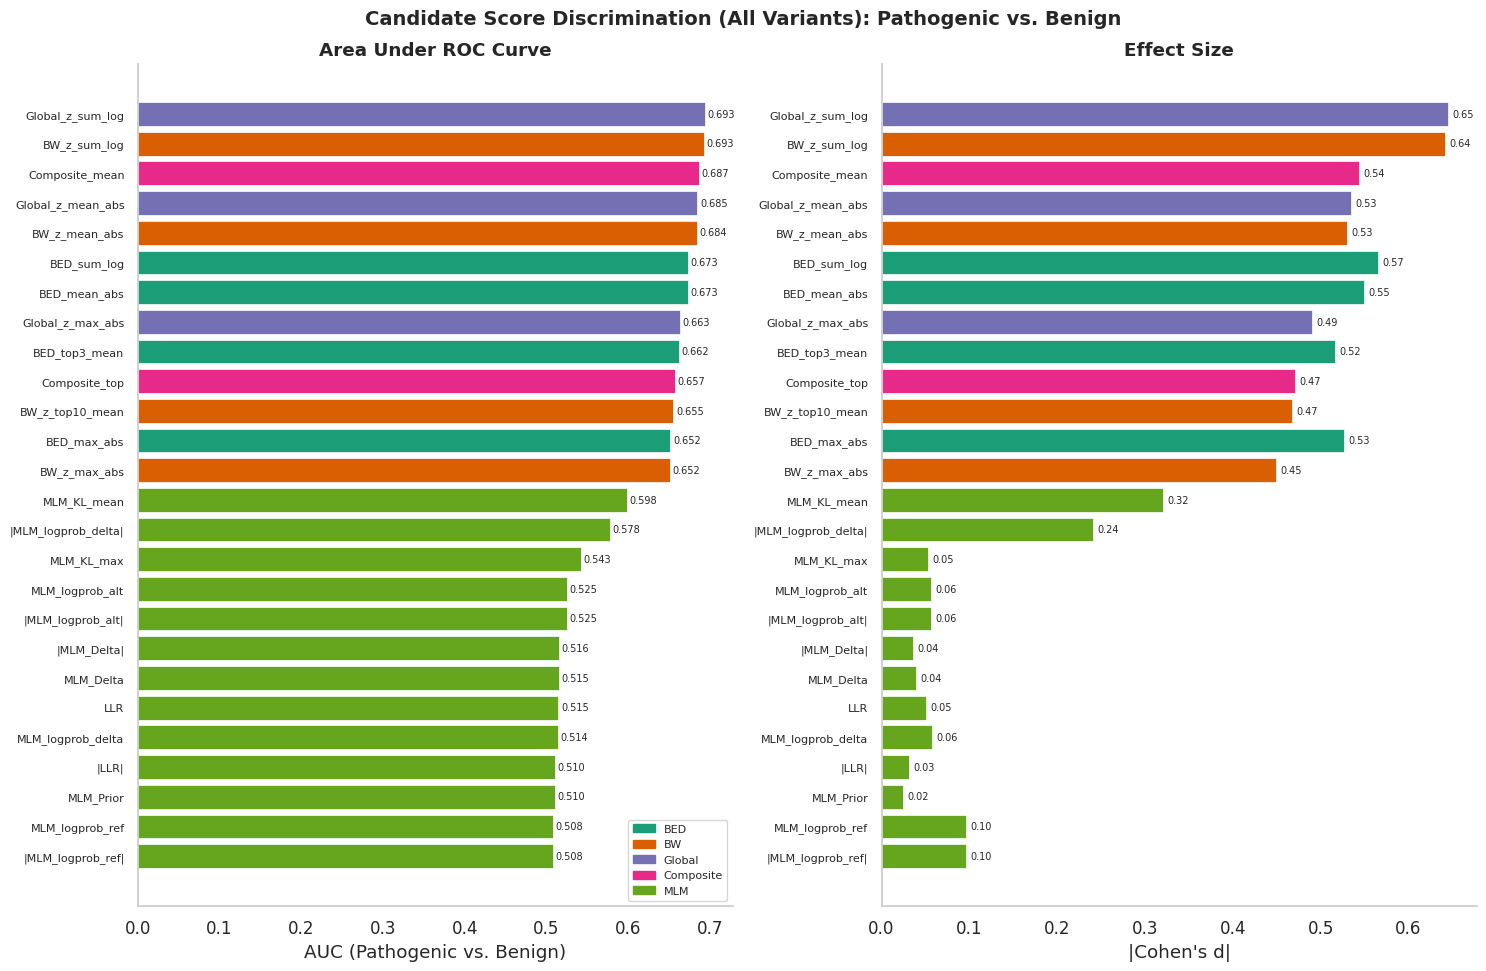

In [9]:
# 4b. VISUALISATION — Ranking Bar Charts (ALL variants only)

GROUP_COLORS = {
    "BED": "#1b9e77",
    "BW": "#d95f02",
    "Global": "#7570b3",
    "Composite": "#e7298a",
    "MLM": "#66a61e",
    "EMB": "#e6ab02",
}

st = (
    score_table[score_table["Subset"] == "All"]
    .sort_values("AUC", ascending=True)
    .copy()
)
colors = [GROUP_COLORS.get(g, "#999") for g in st["Group"]]

fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(st) * 0.38)))

# AUC panel
axes[0].barh(range(len(st)), st["AUC"], color=colors, edgecolor="white", lw=0.5)
axes[0].set_yticks(range(len(st)))
axes[0].set_yticklabels(st["Score"], fontsize=8)
axes[0].set_xlabel("AUC (Pathogenic vs. Benign)")
axes[0].set_title("Area Under ROC Curve", fontweight="bold")
for i, v in enumerate(st["AUC"]):
    axes[0].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=7)

# Effect size panel
axes[1].barh(range(len(st)), st["Cohen_d"], color=colors, edgecolor="white", lw=0.5)
axes[1].set_yticks(range(len(st)))
axes[1].set_yticklabels(st["Score"], fontsize=8)
axes[1].set_xlabel("|Cohen's d|")
axes[1].set_title("Effect Size", fontweight="bold")
for i, v in enumerate(st["Cohen_d"]):
    axes[1].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=7)

# Cleaner look: no gridlines/guide lines
for ax in axes:
    ax.grid(False)

from matplotlib.patches import Patch

leg = [
    Patch(color=c, label=g) for g, c in GROUP_COLORS.items() if g in set(st["Group"])
]
axes[0].legend(handles=leg, loc="lower right", fontsize=8)

plt.suptitle(
    "Candidate Score Discrimination (All Variants): Pathogenic vs. Benign",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "SUP_FIG-1_score_ranking_barchart_all_variants.png",
    dpi=300,
    bbox_inches="tight",
)
# plt.savefig(
#     FIG_DIR / "SUP_FIG-1_score_ranking_barchart_all_variants.pdf", bbox_inches="tight"
# )
plt.show()

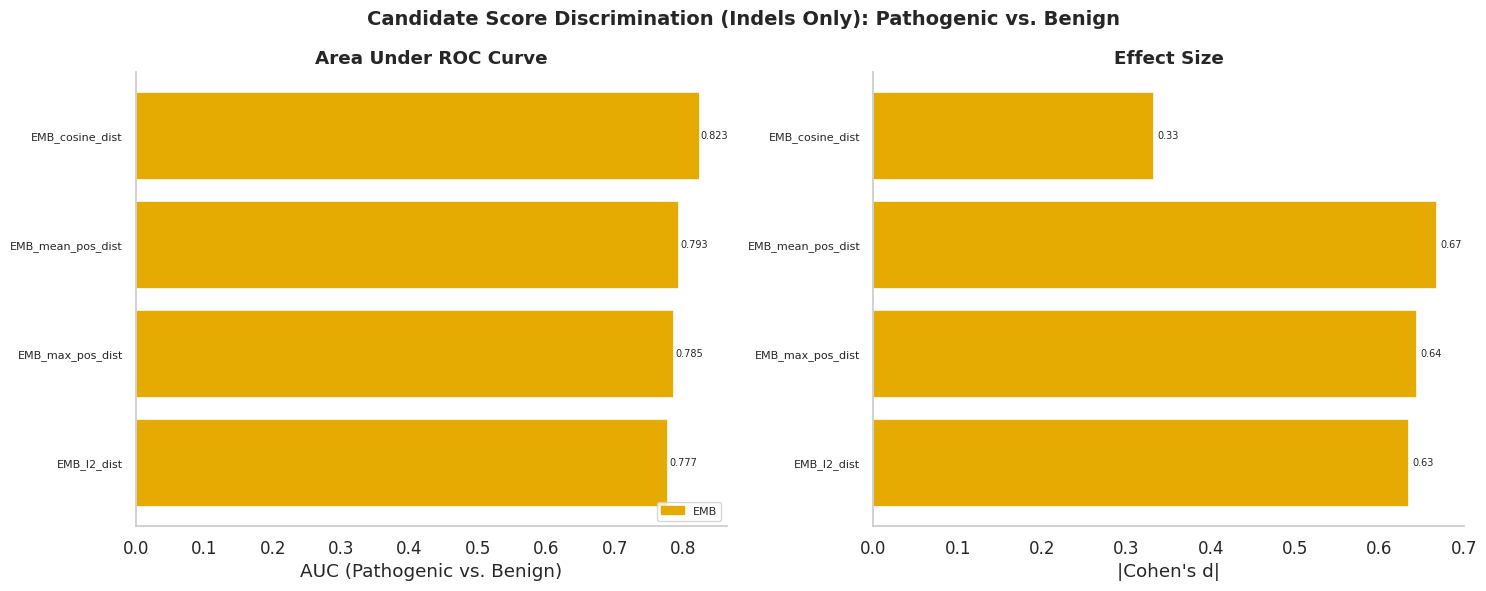

✓ Companion indel-only ranking chart saved.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4b-COMPANION. VISUALISATION — Ranking Bar Charts (INDELS ONLY, EMB focus)
# ═══════════════════════════════════════════════════════════════════════════════
# Separate companion figure highlighting EMB performance on indels

GROUP_COLORS_INDEL = {
    "BED": "#1b9e77",
    "BW": "#d95f02",
    "Global": "#7570b3",
    "Composite": "#e7298a",
    "MLM": "#66a61e",
    "EMB": "#e6ab02",
}

st_indel = (
    score_table[score_table["Subset"] == "Indels"]
    .sort_values("AUC", ascending=True)
    .copy()
)

if len(st_indel) > 0:
    colors_indel = [GROUP_COLORS_INDEL.get(g, "#999") for g in st_indel["Group"]]

    fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(st_indel) * 0.38)))

    # AUC panel
    axes[0].barh(
        range(len(st_indel)),
        st_indel["AUC"],
        color=colors_indel,
        edgecolor="white",
        lw=0.5,
    )
    axes[0].set_yticks(range(len(st_indel)))
    axes[0].set_yticklabels(st_indel["Score"], fontsize=8)
    axes[0].set_xlabel("AUC (Pathogenic vs. Benign)")
    axes[0].set_title("Area Under ROC Curve", fontweight="bold")
    for i, v in enumerate(st_indel["AUC"]):
        axes[0].text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=7)

    # Effect size panel
    axes[1].barh(
        range(len(st_indel)),
        st_indel["Cohen_d"],
        color=colors_indel,
        edgecolor="white",
        lw=0.5,
    )
    axes[1].set_yticks(range(len(st_indel)))
    axes[1].set_yticklabels(st_indel["Score"], fontsize=8)
    axes[1].set_xlabel("|Cohen's d|")
    axes[1].set_title("Effect Size", fontweight="bold")
    for i, v in enumerate(st_indel["Cohen_d"]):
        axes[1].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=7)

    # Cleaner look: no gridlines
    for ax in axes:
        ax.grid(False)

    from matplotlib.patches import Patch

    leg = [
        Patch(color=c, label=g)
        for g, c in GROUP_COLORS_INDEL.items()
        if g in set(st_indel["Group"])
    ]
    axes[0].legend(handles=leg, loc="lower right", fontsize=8)

    plt.suptitle(
        "Candidate Score Discrimination (Indels Only): Pathogenic vs. Benign",
        fontweight="bold",
        fontsize=14,
    )
    plt.tight_layout()
    # plt.savefig(
    #     FIG_DIR / "SUP_FIG-1b_score_ranking_barchart_indels_only.png",
    #     dpi=300,
    #     bbox_inches="tight",
    # )

    plt.show()
    print("✓ Companion indel-only ranking chart saved.")
else:
    print("⚠ No indel-subset scores available for companion figure.")


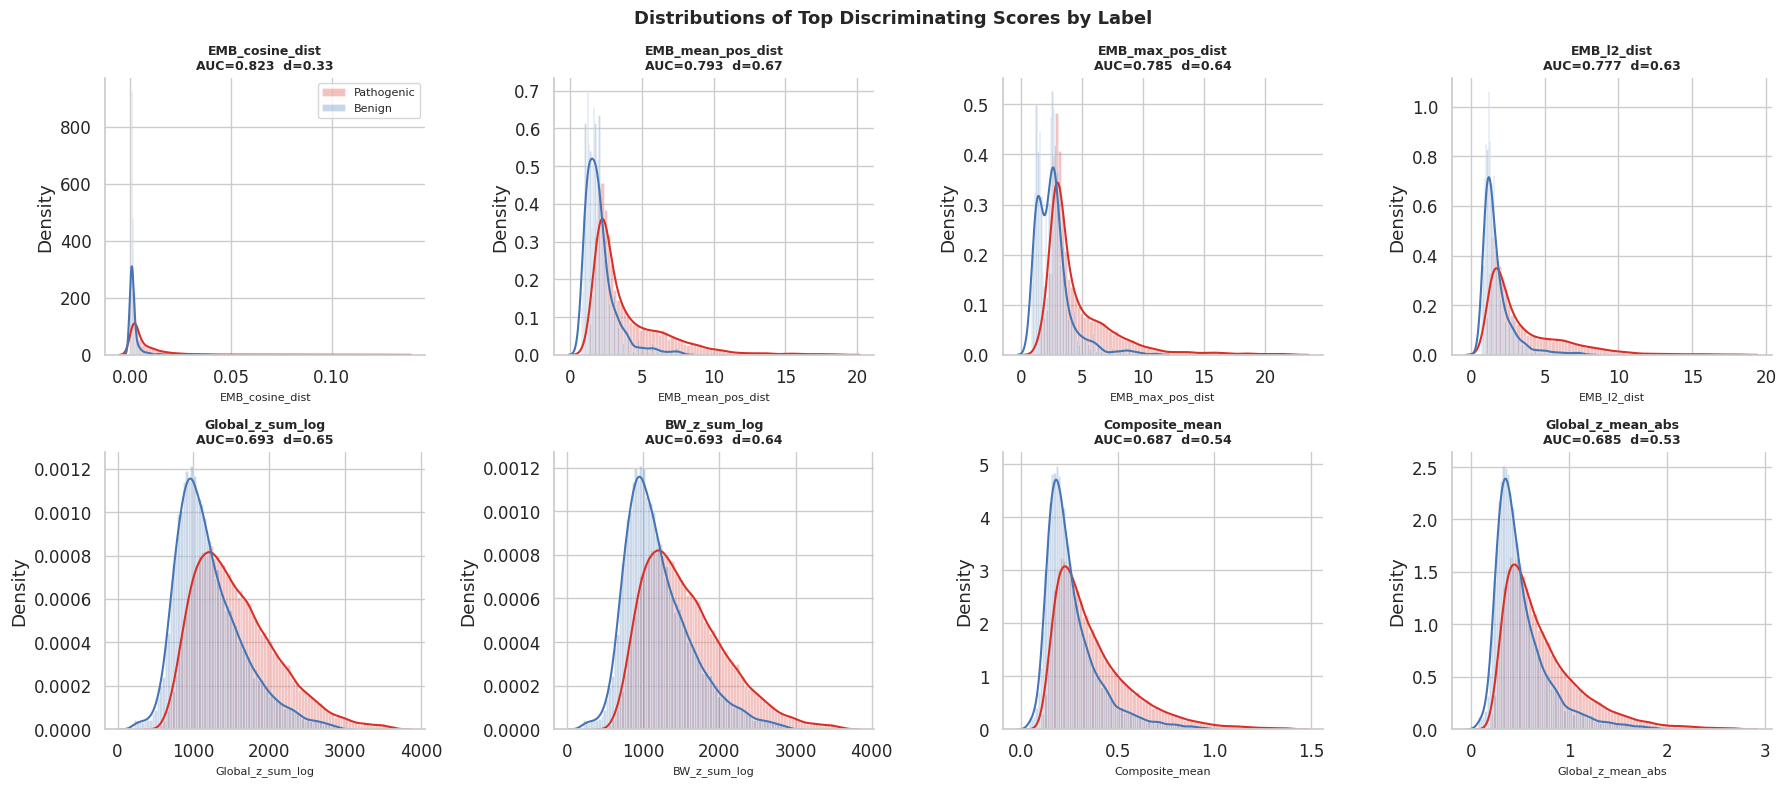

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4c. KDE OVERLAYS — Top-8 scoring candidates
# ═══════════════════════════════════════════════════════════════════════════════
TOP_N = 8
top_entries = score_table.head(TOP_N)

# Build a lookup from score_registry for value retrieval
reg_lookup = {name: (vals, subset) for name, vals, subset, _ in score_registry}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(top_entries.iterrows()):
    ax = axes[i]
    sname = row["Score"]
    vals_full, subset = reg_lookup[sname]

    for lbl, color in LABEL_COLORS.items():
        if subset == "Indels":
            lbl_mask = (df["label"] == lbl).values & indel_mask
        else:
            lbl_mask = (df["label"] == lbl).values
        v = vals_full[lbl_mask]
        v = v[np.isfinite(v)]
        lo, hi = np.percentile(v, [0.5, 99.5])
        v = v[(v >= lo) & (v <= hi)]
        ax.hist(v, bins=80, density=True, alpha=0.3, color=color, label=lbl)
        try:
            sns.kdeplot(v, ax=ax, color=color, linewidth=1.5)
        except Exception:
            pass

    ax.set_title(
        f"{sname}\nAUC={row['AUC']:.3f}  d={row['Cohen_d']:.2f}",
        fontsize=9,
        fontweight="bold",
    )
    ax.set_xlabel(sname, fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle(
    "Distributions of Top Discriminating Scores by Label",
    fontweight="bold",
    fontsize=13,
)
plt.tight_layout()
# plt.savefig(FIG_DIR / "top_score_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4d. Per-Group Aggregation Comparison

Which aggregation method (mean, max, sum_log, top-k) works best within each group?

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4d. WITHIN-GROUP AGGREGATION COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════
for grp in ["BED", "BW", "Composite", "Global"]:
    sub = all_scores[all_scores["Group"] == grp].sort_values("AUC", ascending=False)
    if len(sub) == 0:
        continue
    print(f"\n{'─' * 50}")
    print(f"Group: {grp}")
    print(f"{'─' * 50}")
    for _, r in sub.iterrows():
        flag = " ★" if r["AUC"] == sub["AUC"].max() else ""
        print(f"  {r['Score']:<25s}  AUC={r['AUC']:.4f}  d={r['Cohen_d']:.3f}{flag}")

# MLM summary
mlm_sub = all_scores[all_scores["Group"] == "MLM"].sort_values("AUC", ascending=False)
print(f"\n{'─' * 50}")
print(f"Group: MLM (individual features)")
print(f"{'─' * 50}")
for _, r in mlm_sub.iterrows():
    flag = " ★" if r["AUC"] == mlm_sub["AUC"].max() else ""
    print(f"  {r['Score']:<25s}  AUC={r['AUC']:.4f}  d={r['Cohen_d']:.3f}{flag}")

# EMB summary (indel-only)
emb_sub = score_table[score_table["Group"] == "EMB"].sort_values("AUC", ascending=False)
if len(emb_sub):
    print(f"\n{'─' * 50}")
    print(f"Group: EMB (indel-only)")
    print(f"{'─' * 50}")
    for _, r in emb_sub.iterrows():
        flag = " ★" if r["AUC"] == emb_sub["AUC"].max() else ""
        print(f"  {r['Score']:<25s}  AUC={r['AUC']:.4f}  d={r['Cohen_d']:.3f}{flag}")


──────────────────────────────────────────────────
Group: BED
──────────────────────────────────────────────────
  BED_sum_log                AUC=0.6730  d=0.565 ★
  BED_mean_abs               AUC=0.6729  d=0.549
  BED_top3_mean              AUC=0.6621  d=0.517
  BED_max_abs                AUC=0.6516  d=0.526

──────────────────────────────────────────────────
Group: BW
──────────────────────────────────────────────────
  BW_z_sum_log               AUC=0.6925  d=0.642 ★
  BW_z_mean_abs              AUC=0.6837  d=0.531
  BW_z_top10_mean            AUC=0.6553  d=0.467
  BW_z_max_abs               AUC=0.6515  d=0.449

──────────────────────────────────────────────────
Group: Composite
──────────────────────────────────────────────────
  Composite_mean             AUC=0.6870  d=0.544 ★
  Composite_top              AUC=0.6566  d=0.471

──────────────────────────────────────────────────
Group: Global
──────────────────────────────────────────────────
  Global_z_sum_log           AUC=0.6933 

---
## 5. Paper Figure — Impact Score vs. gnomAD AF

### Definition used in this notebook (continuous MAGI score)
For each variant, the **continuous MAGI score** is a real-valued burden score where
higher values indicate larger functional deviation between ALT and REF predictions.

In this notebook, the score used for Figure 2B is selected from candidate scores
by discrimination performance (AUC) and then treated as MAGI for plotting.
For the current run, this is typically `Global_z_sum_log`, i.e.:

**MAGI(v) = Σⱼ log(1 + |zⱼ(v)|)**, over all z-scored delta tracks (BED + BigWig).

This is a **continuous ranking score**, not a probability; no fixed pathogenic
cutoff is assumed. The horizontal line in the plot is the median pathogenic score
used as a visual reference only.

Paper figure score: Global_z_sum_log
N plotted: 9,619  (Pathogenic: 6,330, Benign: 3,289)
Impact threshold (median Path): 1409.6125
✓ Winner scatter saved.


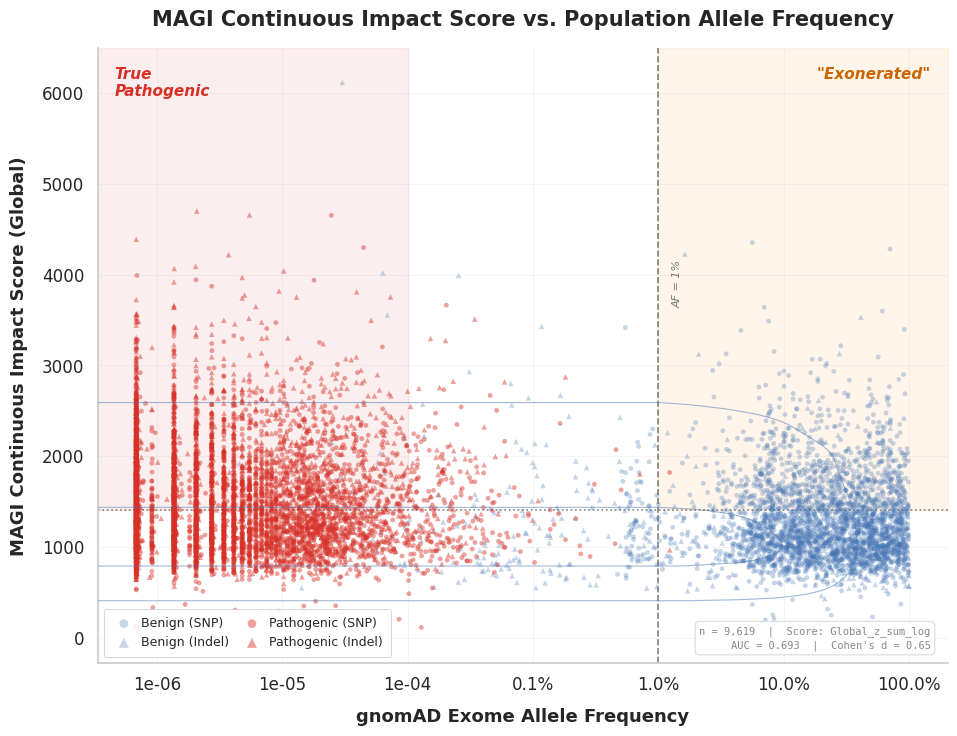

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5a. PAPER-READY SCATTER — Winner
# ═══════════════════════════════════════════════════════════════════════════════

# ── Resolve winning score values ──────────────────────────────────────────────
WIN_NAME = winner["Score"]
# score_registry entries are (name, values_array, subset, group)
entry = next((v for v in score_registry if v[0] == WIN_NAME), None)
if entry is None:
    raise ValueError(f"Winner score '{WIN_NAME}' not found in score_registry")
_, win_vals, _, _ = entry

# Define a single continuous MAGI score column used throughout plotting
if WIN_NAME in df.columns:
    df["MAGI_score_continuous"] = pd.to_numeric(df[WIN_NAME], errors="coerce")
else:
    df["MAGI_score_continuous"] = pd.to_numeric(win_vals, errors="coerce")

SCORE_COL = "MAGI_score_continuous"

# ── Build plot DataFrame (variants with AF > 0) ──────────────────────────────
# Filter: gnomAD AF must be present, > 0 (to avoid -inf in log), score must be finite
valid_mask = (
    (df["gnomADe_AF"].notna())
    & (df["gnomADe_AF"] > 0)
    & (df[SCORE_COL].notna())
    & (np.isfinite(df[SCORE_COL].values))
)
plot_df = df[valid_mask].copy()
plot_df["log10_AF"] = np.log10(plot_df["gnomADe_AF"])
# Extra safeguard: remove any remaining inf/-inf values in log10_AF or SCORE_COL
plot_df = plot_df[
    np.isfinite(plot_df["log10_AF"]) & np.isfinite(plot_df[SCORE_COL])
].copy()
if plot_df.empty:
    raise ValueError("No variants left after AF/finite MAGI filtering")

# Impact threshold = median of pathogenic scores
IMPACT_THRESH = plot_df.loc[plot_df["label"] == "Pathogenic", SCORE_COL].median()

print(f"Paper figure score: {WIN_NAME}")
print(
    f"N plotted: {len(plot_df):,}  (Pathogenic: {(plot_df['label'] == 'Pathogenic').sum():,}, "
    f"Benign: {(plot_df['label'] == 'Benign').sum():,})"
)
print(f"Impact threshold (median Path): {IMPACT_THRESH:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7.5))

# Scatter plot: Benign (background) then Pathogenic (foreground)
for lbl, zo, alpha in [("Benign", 2, 0.30), ("Pathogenic", 3, 0.45)]:
    sub = plot_df[plot_df["label"] == lbl]
    is_snp = sub["variant_type"] == "SNP"
    if is_snp.any():
        ax.scatter(
            sub.loc[is_snp, "gnomADe_AF"],
            sub.loc[is_snp, SCORE_COL],
            c=LABEL_COLORS[lbl],
            s=12,
            alpha=alpha,
            edgecolors="none",
            marker="o",
            zorder=zo,
            rasterized=True,
            label=f"{lbl} (SNP)",
        )
    if (~is_snp).any():
        ax.scatter(
            sub.loc[~is_snp, "gnomADe_AF"],
            sub.loc[~is_snp, SCORE_COL],
            c=LABEL_COLORS[lbl],
            s=16,
            alpha=alpha,
            edgecolors="none",
            marker="^",
            zorder=zo,
            rasterized=True,
            label=f"{lbl} (Indel)",
        )

# KDE contours (subtle background)
for lbl in ["Benign", "Pathogenic"]:
    sub = plot_df[plot_df["label"] == lbl]
    try:
        sns.kdeplot(
            x=sub["log10_AF"],
            y=sub[SCORE_COL],
            ax=ax,
            color=LABEL_COLORS[lbl],
            levels=4,
            linewidths=0.8,
            alpha=0.5,
            zorder=4,
        )
    except Exception:
        pass

# Axis setup
ax.set_xscale("log")
ax.set_xlabel(
    "gnomAD Exome Allele Frequency", fontsize=13, fontweight="bold", labelpad=10
)
ax.set_ylabel(
    f"MAGI Continuous Impact Score ({winner['Group']})",
    fontsize=13,
    fontweight="bold",
    labelpad=10,
)

# Improve tick label formatting
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, p: f"{x:.0e}" if x < 1e-3 else f"{x:.1%}")
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=7, steps=[1, 2, 5, 10]))
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)

# Get current axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Reference threshold lines
ax.axhline(IMPACT_THRESH, color="#333333", ls=":", lw=1.2, alpha=0.6, zorder=1)
ax.axvline(AF_COMMON, color="#333333", ls="--", lw=1.2, alpha=0.6, zorder=1)

# Shaded background zones (subtle)
ax.fill_between(
    [AF_COMMON, xlim[1]], IMPACT_THRESH, ylim[1], alpha=0.08, color="#ff8c00", zorder=0
)
ax.fill_between(
    [xlim[0], AF_RARE], IMPACT_THRESH, ylim[1], alpha=0.08, color="#d73027", zorder=0
)

# Set limits explicitly after shading
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# ── Zone labels: placed at top of shaded zones (sparse-data region) ───────────
# Nature Methods style: clean italic text, no arrows, no heavy borders
ax.text(
    0.02,
    0.97,
    "True\nPathogenic",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    fontstyle="italic",
    color="#d73027",
    ha="left",
    va="top",
    zorder=20,
)
ax.text(
    0.98,
    0.97,
    '"Exonerated"',
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    fontstyle="italic",
    color="#cc6600",
    ha="right",
    va="top",
    zorder=20,
)

# AF=1% label — subtle, near line at mid-height
ax.text(
    AF_COMMON * 1.3,
    ylim[1] * 0.60,
    "AF = 1%",
    fontsize=8,
    color="#777777",
    va="center",
    ha="left",
    fontstyle="italic",
    rotation=90,
    zorder=20,
)

# Legend (lower left — empty region below rare pathogenic cluster)
leg = ax.legend(
    loc="lower left",
    fontsize=9,
    framealpha=0.92,
    edgecolor="#cccccc",
    markerscale=1.8,
    ncol=2,
    frameon=True,
    fancybox=True,
    borderpad=0.6,
    handletextpad=0.4,
    columnspacing=0.8,
)
leg.get_frame().set_linewidth(0.6)

# Metadata box (lower right, compact)
info_text = (
    f"n = {len(plot_df):,}  |  Score: {WIN_NAME}\n"
    f"AUC = {winner['AUC']:.3f}  |  Cohen's d = {winner['Cohen_d']:.2f}"
)
ax.text(
    0.98,
    0.02,
    info_text,
    transform=ax.transAxes,
    fontsize=7.5,
    color="#888888",
    va="bottom",
    ha="right",
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.4", facecolor="white", edgecolor="#dddddd", alpha=0.90
    ),
    linespacing=1.4,
)

# Title
ax.set_title(
    "MAGI Continuous Impact Score vs. Population Allele Frequency",
    fontsize=15,
    fontweight="bold",
    pad=16,
)

# Finalize layout with extra space for annotations
plt.subplots_adjust(left=0.1, right=0.95, top=0.93, bottom=0.11)

# plt.savefig(FIG_DIR / "fig2b_winner_scatter.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIG_DIR / "fig2b_winner_scatter.png", dpi=300, bbox_inches="tight")
print("✓ Winner scatter saved.")
plt.show()

✓ Winner JointGrid saved.


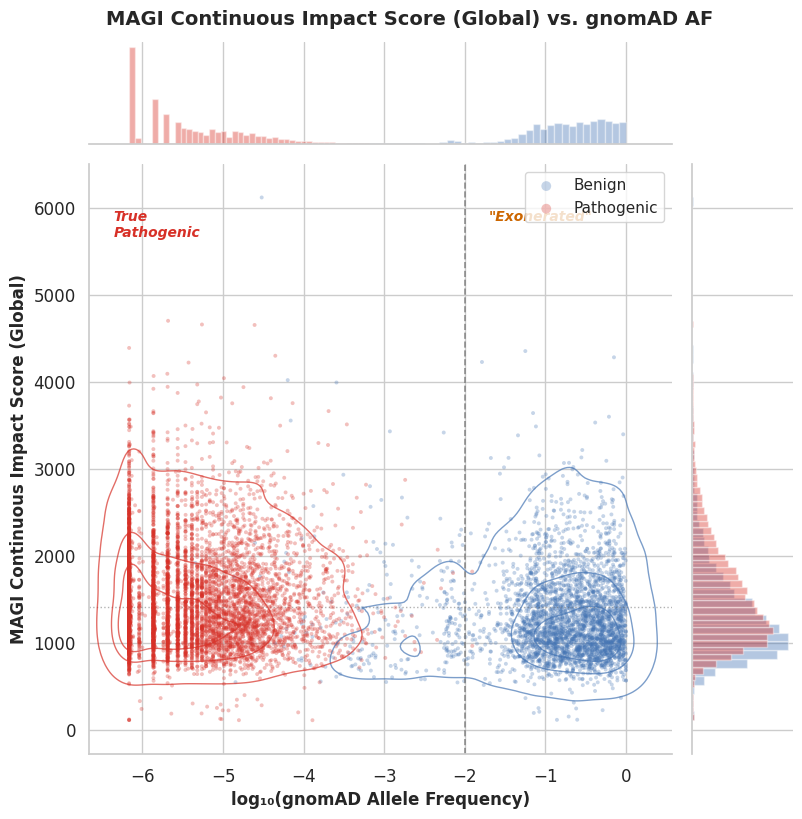

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5b. JOINTGRID VERSION  (with marginal distributions)
# ═══════════════════════════════════════════════════════════════════════════════
g = sns.JointGrid(data=plot_df, x="log10_AF", y=SCORE_COL, height=8, ratio=5)

for lbl, zo in [("Benign", 2), ("Pathogenic", 3)]:
    sub = plot_df[plot_df["label"] == lbl]
    g.ax_joint.scatter(
        sub["log10_AF"],
        sub[SCORE_COL],
        c=LABEL_COLORS[lbl],
        label=lbl,
        s=8,
        alpha=0.3,
        edgecolors="none",
        zorder=zo,
        rasterized=True,
    )

for lbl in ["Benign", "Pathogenic"]:
    sub = plot_df[plot_df["label"] == lbl]
    try:
        sns.kdeplot(
            x=sub["log10_AF"],
            y=sub[SCORE_COL],
            ax=g.ax_joint,
            color=LABEL_COLORS[lbl],
            levels=4,
            linewidths=1.0,
            alpha=0.7,
            zorder=4,
        )
    except Exception:
        pass
    g.ax_marg_x.hist(
        sub["log10_AF"], bins=60, alpha=0.4, color=LABEL_COLORS[lbl], density=True
    )
    g.ax_marg_y.hist(
        sub[SCORE_COL],
        bins=60,
        alpha=0.4,
        color=LABEL_COLORS[lbl],
        density=True,
        orientation="horizontal",
    )

g.ax_joint.axvline(np.log10(AF_COMMON), color="#666", ls="--", lw=1.2, alpha=0.7)
g.ax_joint.axhline(IMPACT_THRESH, color="#666", ls=":", lw=1.0, alpha=0.5)
g.ax_joint.set_xlabel("log₁₀(gnomAD Allele Frequency)", fontsize=12, fontweight="bold")
g.ax_joint.set_ylabel(
    f"MAGI Continuous Impact Score ({winner['Group']})", fontsize=12, fontweight="bold"
)
g.ax_joint.legend(loc="upper right", fontsize=11, markerscale=2.5)

# Zone labels
jx, jy = g.ax_joint.get_xlim(), g.ax_joint.get_ylim()
g.ax_joint.annotate(
    '"Exonerated"',
    xy=(np.log10(AF_COMMON) + 0.3, jy[1] * 0.92),
    fontsize=10,
    fontstyle="italic",
    color="#cc6600",
    fontweight="bold",
    ha="left",
    va="top",
)
g.ax_joint.annotate(
    "True\nPathogenic",
    xy=(jx[0] + 0.3, jy[1] * 0.92),
    fontsize=10,
    fontstyle="italic",
    color="#d73027",
    fontweight="bold",
    ha="left",
    va="top",
)

g.fig.suptitle(
    f"MAGI Continuous Impact Score ({winner['Group']}) vs. gnomAD AF",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.savefig(FIG_DIR / "fig2b_winner_joint.png", dpi=300, bbox_inches="tight")
print("✓ Winner JointGrid saved.")
plt.show()

---
## 6. Supplementary Panels

Additional figures for the paper supplement:
1. **Best composite score** scatter (if winner is a raw/individual score)
2. **KL divergence** violin plots (Pathogenic vs. Benign)
3. **Embedding distance** violin plots (indels only)
4. **Quadrant analysis** — counts per AF × Impact quadrant

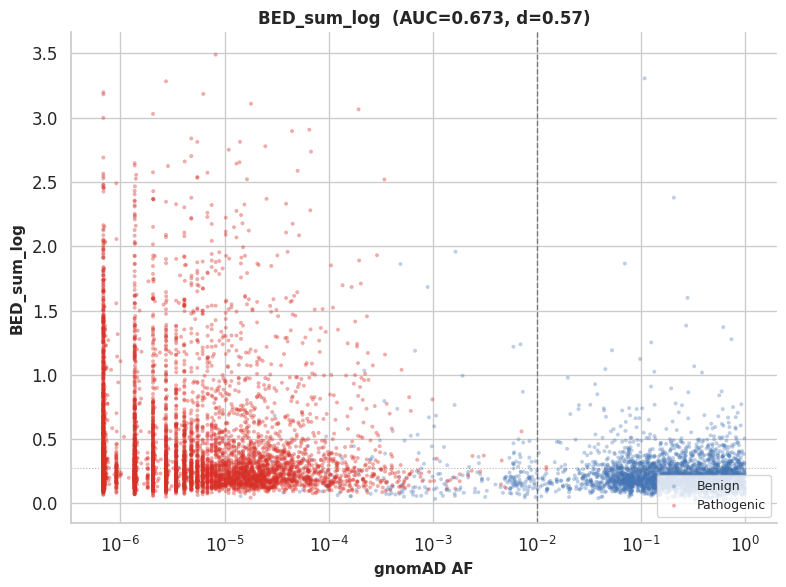

✓ Supplementary: BED_sum_log


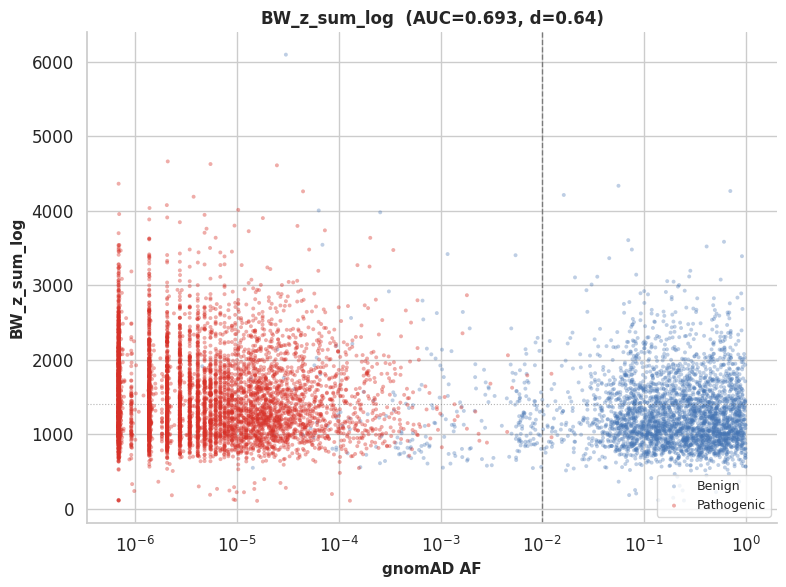

✓ Supplementary: BW_z_sum_log


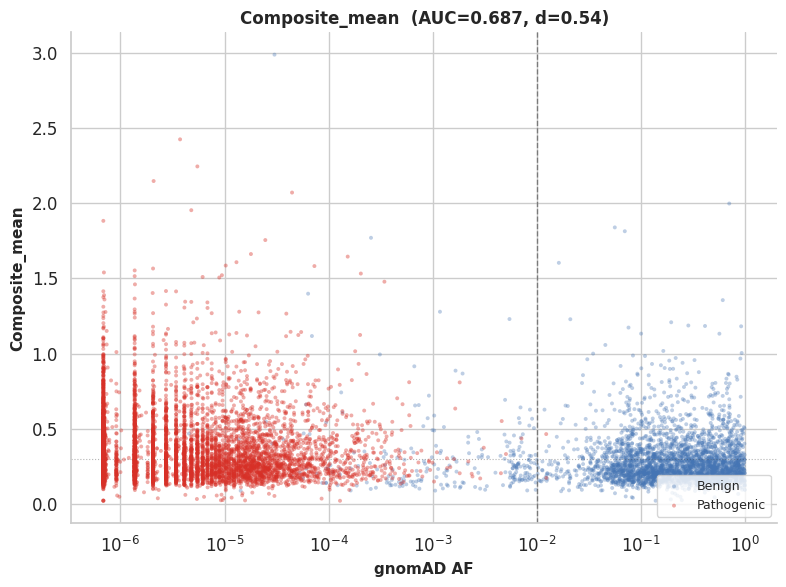

✓ Supplementary: Composite_mean


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6a. BEST COMPOSITE / GROUP SCORE SCATTERS
# ═══════════════════════════════════════════════════════════════════════════════
# Generate supplementary scatters for the top score in each major group
SUPP_GROUPS = ["BED", "BW", "Composite", "Global"]
for grp in SUPP_GROUPS:
    grp_best = all_scores[all_scores["Group"] == grp]
    if grp_best.empty:
        continue
    best = grp_best.iloc[0]
    sname = best["Score"]
    if sname == WIN_NAME:
        continue  # already have the main figure for this score

    scol = sname if sname in df.columns else None
    if scol is None:
        continue

    pdf = plot_df.copy()
    if scol not in pdf.columns:
        continue
    pdf = pdf[pdf[scol].notna()]
    thresh = pdf.loc[pdf["label"] == "Pathogenic", scol].median()

    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl, zo, alpha in [("Benign", 2, 0.35), ("Pathogenic", 3, 0.40)]:
        sub = pdf[pdf["label"] == lbl]
        ax.scatter(
            sub["gnomADe_AF"],
            sub[scol],
            c=LABEL_COLORS[lbl],
            s=8,
            alpha=alpha,
            edgecolors="none",
            zorder=zo,
            rasterized=True,
            label=lbl,
        )
    ax.set_xscale("log")
    ax.axvline(AF_COMMON, color="#444", ls="--", lw=1.0, alpha=0.6)
    ax.axhline(thresh, color="#444", ls=":", lw=0.8, alpha=0.4)
    ax.set_xlabel("gnomAD AF", fontsize=11, fontweight="bold")
    ax.set_ylabel(sname, fontsize=11, fontweight="bold")
    ax.set_title(
        f"{sname}  (AUC={best['AUC']:.3f}, d={best['Cohen_d']:.2f})",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    safe = sname.replace("|", "").replace("/", "_")
    plt.savefig(FIG_DIR / f"supp_{safe}_vs_af.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"supp_{safe}_vs_af.pdf", bbox_inches="tight")
    plt.show()
    print(f"✓ Supplementary: {sname}")

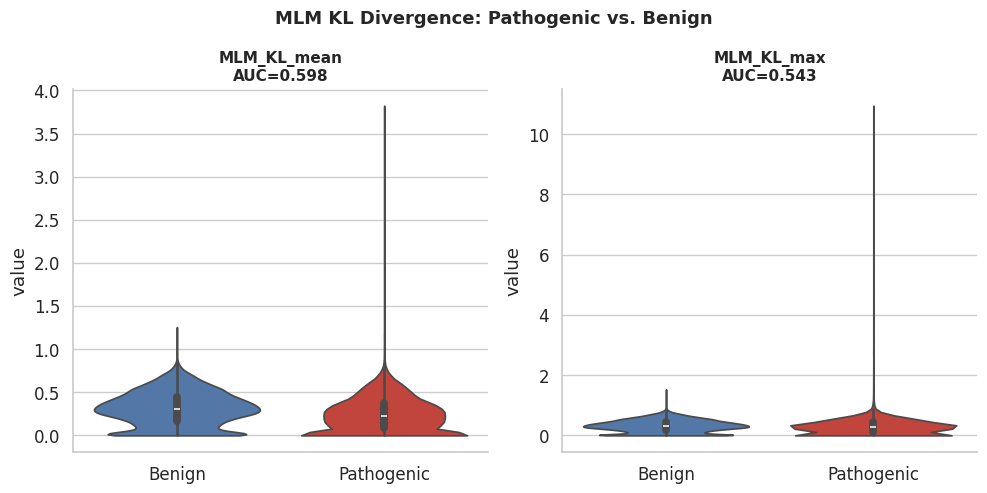

✓ KL violin plots


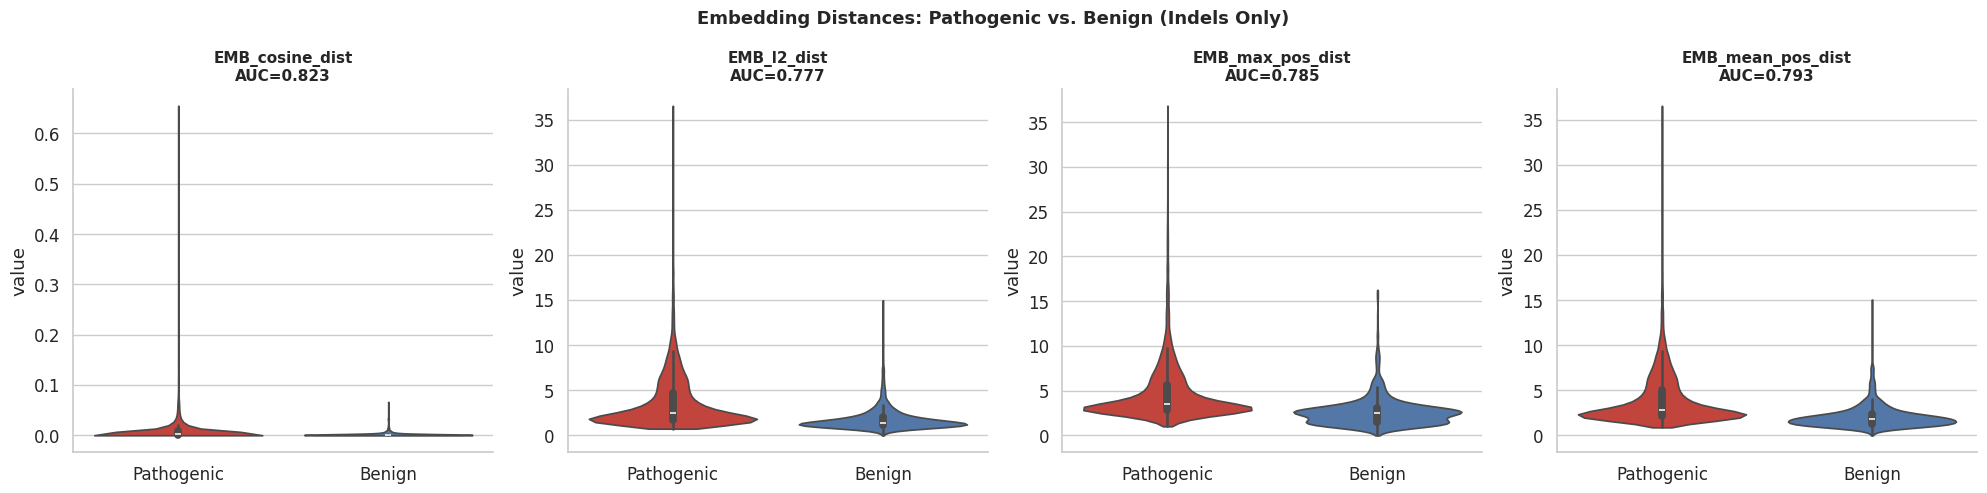

✓ Embedding violin plots


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6b. KL DIVERGENCE & MLM VIOLIN PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
kl_cols = [c for c in ["MLM_KL_mean", "MLM_KL_max"] if c in df.columns]
if kl_cols:
    fig, axes = plt.subplots(1, len(kl_cols), figsize=(5 * len(kl_cols), 5))
    if len(kl_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, kl_cols):
        data_long = pd.DataFrame(
            {
                "value": df[col].values,
                "label": df["label"].values,
            }
        ).dropna()
        sns.violinplot(
            data=data_long,
            x="label",
            y="value",
            hue="label",
            palette=LABEL_COLORS,
            ax=ax,
            inner="box",
            cut=0,
            density_norm="width",
        )
        # AUC annotation
        row_kl = score_table[score_table["Score"] == col]
        if not row_kl.empty:
            ax.set_title(
                f"{col}\nAUC={row_kl.iloc[0]['AUC']:.3f}",
                fontsize=11,
                fontweight="bold",
            )
        else:
            ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.get_legend().remove() if ax.get_legend() else None
    plt.suptitle(
        "MLM KL Divergence: Pathogenic vs. Benign", fontweight="bold", fontsize=13
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "supp_kl_violins.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ KL violin plots")

# ── Embedding distance violins (indel-only) ──────────────────────────────────
emb_present = [c for c in EMB if c in df.columns]
if emb_present:
    fig, axes = plt.subplots(1, len(emb_present), figsize=(5 * len(emb_present), 5))
    if len(emb_present) == 1:
        axes = [axes]
    indel_df_plot = df[
        df["variant_type"].isin(
            ["Indel", "indel", "deletion", "insertion", "Deletion", "Insertion"]
        )
    ]
    for ax, col in zip(axes, emb_present):
        data_long = pd.DataFrame(
            {
                "value": indel_df_plot[col].values,
                "label": indel_df_plot["label"].values,
            }
        ).dropna()
        sns.violinplot(
            data=data_long,
            x="label",
            y="value",
            hue="label",
            palette=LABEL_COLORS,
            ax=ax,
            inner="box",
            cut=0,
            density_norm="width",
        )
        row_e = score_table[score_table["Score"] == col]
        if not row_e.empty:
            ax.set_title(
                f"{col}\nAUC={row_e.iloc[0]['AUC']:.3f}", fontsize=11, fontweight="bold"
            )
        else:
            ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.get_legend().remove() if ax.get_legend() else None
    plt.suptitle(
        "Embedding Distances: Pathogenic vs. Benign (Indels Only)",
        fontweight="bold",
        fontsize=13,
    )
    plt.tight_layout()
    # plt.savefig(FIG_DIR / "supp_emb_violins.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ Embedding violin plots")

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6c. QUADRANT ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
hi = plot_df[SCORE_COL] >= IMPACT_THRESH
rare = plot_df["gnomADe_AF"] < AF_COMMON

quads = {
    "High Impact & Rare (<1%)": hi & rare,
    "High Impact & Common (≥1%)": hi & ~rare,
    "Low Impact & Rare (<1%)": ~hi & rare,
    "Low Impact & Common (≥1%)": ~hi & ~rare,
}

print(f"\n{'═' * 70}")
print(
    f"QUADRANT ANALYSIS  (AF threshold = {AF_COMMON}, Impact threshold = {IMPACT_THRESH:.4f})"
)
print(f"{'═' * 70}")
print(f"{'Quadrant':<32s} {'Total':>7s} {'Path':>7s} {'Benign':>7s} {'%Path':>7s}")
print(f"{'─' * 70}")
for qname, qmask in quads.items():
    total = qmask.sum()
    path = (qmask & (plot_df["label"] == "Pathogenic")).sum()
    ben = (qmask & (plot_df["label"] == "Benign")).sum()
    pct = path / max(total, 1) * 100
    print(f"{qname:<32s} {total:>7,} {path:>7,} {ben:>7,} {pct:>6.1f}%")
print(f"{'─' * 70}")
print(f"{'Total':<32s} {len(plot_df):>7,}")


══════════════════════════════════════════════════════════════════════
QUADRANT ANALYSIS  (AF threshold = 0.01, Impact threshold = 1409.6125)
══════════════════════════════════════════════════════════════════════
Quadrant                           Total    Path  Benign   %Path
──────────────────────────────────────────────────────────────────────
High Impact & Rare (<1%)           3,249   3,164      85   97.4%
High Impact & Common (≥1%)           989       1     988    0.1%
Low Impact & Rare (<1%)            3,320   3,164     156   95.3%
Low Impact & Common (≥1%)          2,061       1   2,060    0.0%
──────────────────────────────────────────────────────────────────────
Total                              9,619


---
## 7. Summary &amp; Export

- Score discrimination table → CSV
- Figure caption text
- Experiment tracking: which scores were computed, evaluated, and why the winner was chosen

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. EXPORT & SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

# ── Save ranking table ────────────────────────────────────────────────────────
score_table.to_csv(FIG_DIR / "score_discrimination_table.csv", index=False)
print(f"✓ Score ranking table → {FIG_DIR / 'score_discrimination_table.csv'}")

# ── Figure caption ────────────────────────────────────────────────────────────
caption = f"""
Figure 2B.  MAGI Impact Score ({winner["Group"]}: {WIN_NAME}) plotted against
gnomAD exome allele frequency for {len(plot_df):,} ClinVar variants
({(plot_df["label"] == "Pathogenic").sum():,} pathogenic, {(plot_df["label"] == "Benign").sum():,} benign)
with available gnomAD data.  The impact score was selected from {len(score_registry)}
candidates spanning BED-element deltas, z-scored BigWig track deltas, masked
language model features, and composite aggregations (see Supplementary Table).
{WIN_NAME} achieved the highest area under the ROC curve
(AUC = {winner["AUC"]:.3f}, Cohen's d = {winner["Cohen_d"]:.2f}) for
discriminating pathogenic from benign variants.  Dashed vertical line marks
the ACMG BA1 threshold (AF ≥ 1%); dotted horizontal line marks the median
pathogenic impact score.  Red/blue contours show 2D kernel density estimates.
Circles = SNPs; triangles = indels.
""".strip()

print(f"\n{'═' * 70}")
print("FIGURE CAPTION")
print(f"{'═' * 70}")
print(caption)

# ── Experiment summary ────────────────────────────────────────────────────────
print(f"\n{'═' * 70}")
print("EXPERIMENT TRACKING SUMMARY")
print(f"{'═' * 70}")
print(f"Dataset:       {len(df):,} variants (SNP + Indel)")
print(f"With gnomAD:   {has_af.sum():,} ({has_af.mean():.1%})")
print(f"Plotted (AF>0): {len(plot_df):,}")
print(
    f"Score groups:  BED ({len(D_BED)} cols), BW ({len(D_BW)} cols), "
    f"MLM ({len(MLM)} feats), EMB ({len(EMB)} feats)"
)
print(f"Candidates:    {len(score_registry)} total scores evaluated")
print(f"BW z-scoring:  per-variant-type separate benign baseline")
print(f"Aggregations:  mean|x|, max|x|, Σln(1+|x|), top-k mean")
print(f"")
print(f"TOP 5 SCORES (all-variant subset):")
for i, (_, r) in enumerate(all_scores.head(5).iterrows()):
    marker = "★" if i == 0 else " "
    print(
        f"  {marker} {r['Score']:<25s}  AUC={r['AUC']:.4f}  d={r['Cohen_d']:.3f}  [{r['Group']}]"
    )
print(f"")
print(f"Winner:  {WIN_NAME}  (Group={winner['Group']}, AUC={winner['AUC']:.4f})")
print(f"Figures: {FIG_DIR.resolve()}")
print(f"{'═' * 70}")

✓ Score ranking table → analyses/figures/impact_vs_af/score_discrimination_table.csv

══════════════════════════════════════════════════════════════════════
FIGURE CAPTION
══════════════════════════════════════════════════════════════════════
Figure 2B.  MAGI Impact Score (Global: Global_z_sum_log) plotted against
gnomAD exome allele frequency for 9,619 ClinVar variants
(6,330 pathogenic, 3,289 benign)
with available gnomAD data.  The impact score was selected from 30
candidates spanning BED-element deltas, z-scored BigWig track deltas, masked
language model features, and composite aggregations (see Supplementary Table).
Global_z_sum_log achieved the highest area under the ROC curve
(AUC = 0.693, Cohen's d = 0.65) for
discriminating pathogenic from benign variants.  Dashed vertical line marks
the ACMG BA1 threshold (AF ≥ 1%); dotted horizontal line marks the median
pathogenic impact score.  Red/blue contours show 2D kernel density estimates.
Circles = SNPs; triangles = indels.

═══════